# Diseño de experimentos: comparación de modelos e hiperparámetros para clasificación de textos

**Dataset:** BBC News Articles (2,225 artículos, 5 categorías: business, entertainment, politics, sport, tech)
**Fuente:** BBC News dataset (Greene & Cunningham, 2006), consolidado en CSV público.

Objetivo: diseñar y ejecutar un experimento factorial para determinar qué combinación de
(a) técnica de vectorización, (b) rango de n-gramas y (c) modelo/hiperparámetros
produce el mejor desempeño de clasificación multiclase, con evaluación estadísticamente
rigurosa (validación cruzada + prueba de hipótesis sobre las diferencias).

In [1]:
import re
import time
import json
import itertools
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from scipy import stats

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Carga y preparación de datos

In [2]:
df = pd.read_csv("bbc-text.csv")
df.columns = ["category", "text"]

def clean_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"[^a-z\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["text_clean"] = df["text"].apply(clean_text)
df["n_words"] = df["text_clean"].str.split().apply(len)

print(f"Documentos: {len(df)}")
print(df["category"].value_counts())

Documentos: 2225
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


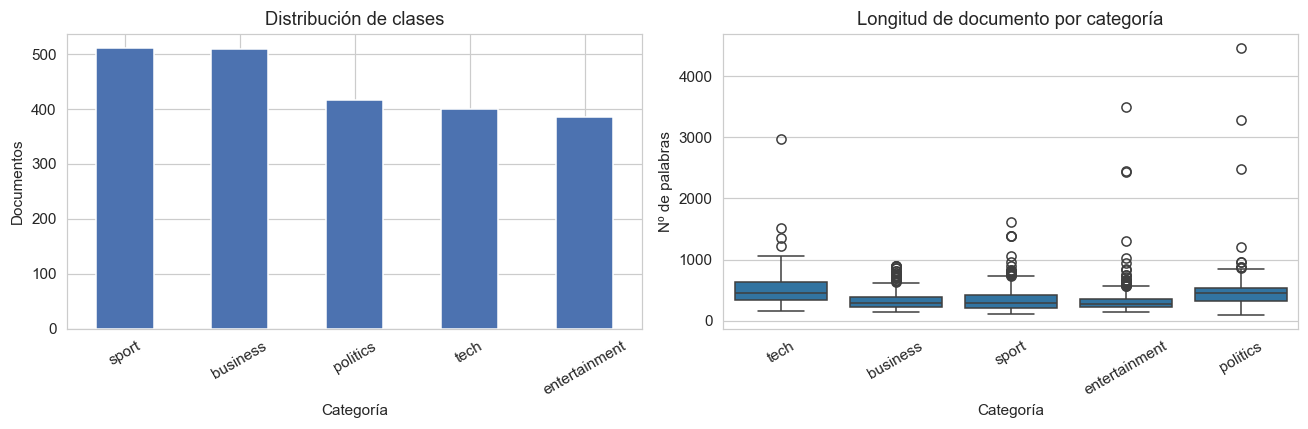

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["category"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de clases")
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Documentos")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="category", y="n_words", ax=axes[1])
axes[1].set_title("Longitud de documento por categoría")
axes[1].set_xlabel("Categoría")
axes[1].set_ylabel("Nº de palabras")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("figs/01_eda.png", bbox_inches="tight")
plt.show()

## 2. Diseño experimental

Se plantea un **diseño factorial cruzado** con tres factores controlados:

| Factor | Niveles | Justificación |
|---|---|---|
| **Vectorización** | TF-IDF, Bag-of-Words (conteo) | Comparar ponderación por relevancia vs. frecuencia cruda |
| **N-gramas** | unigramas (1,1), uni+bigramas (1,2) | Evaluar si el contexto local de 2 palabras aporta señal |
| **Modelo** | Naive Bayes, Regresión Logística, SVM lineal, Random Forest | Cubrir familias generativa, lineal discriminativa, margen máximo y ensamble de árboles |

Cada modelo tiene además su propia rejilla de **hiperparámetros** (factor anidado), de forma
que el experimento completo es un diseño factorial de 2 (vectorización) × 2 (n-gramas) ×
{rejilla de hiperparámetros por modelo}, evaluado con **validación cruzada estratificada de 5
folds** sobre el conjunto de entrenamiento (80%), y una evaluación final independiente sobre
un conjunto de prueba (20%) nunca visto durante la búsqueda.

**Variable de respuesta:** F1-macro (adecuada por el ligero desbalance de clases) y accuracy
como métrica secundaria de referencia.

**Análisis estadístico:** una vez identificada la mejor configuración por modelo, se comparan
los folds de CV de los dos mejores modelos con una prueba t pareada para determinar si la
diferencia observada es estadísticamente significativa (α = 0.05), evitando concluir
superioridad a partir de una única corrida.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_clean"], df["category"],
    test_size=0.20, stratify=df["category"], random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 1780  Test: 445


## 3. Espacio de búsqueda por modelo

Para cada modelo se define un `Pipeline` (vectorizador → clasificador) y una rejilla que cruza
los factores de vectorización/n-gramas con los hiperparámetros propios del modelo.

In [5]:
vec_grid = {
    "vec": [TfidfVectorizer(max_features=6000, min_df=2), CountVectorizer(max_features=6000, min_df=2)],
    "vec__ngram_range": [(1, 1), (1, 2)],
}

model_grids = {
    "MultinomialNB": {
        "clf": [MultinomialNB()],
        "clf__alpha": [0.05, 0.3, 1.0],
    },
    "LogisticRegression": {
        "clf": [LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)],
        "clf__C": [0.1, 1, 10],
    },
    "LinearSVC": {
        "clf": [LinearSVC(random_state=RANDOM_STATE)],
        "clf__C": [0.01, 0.1, 1],
    },
    "RandomForest": {
        "clf": [RandomForestClassifier(random_state=RANDOM_STATE)],
        "clf__n_estimators": [100, 250],
        "clf__max_depth": [None, 40],
    },
}

results = []
best_estimators = {}
cv_scores_best = {}
all_rows = []  # para el análisis de factores de la sección 4.1 (se llena reutilizando cv_results_)

for name, grid in model_grids.items():
    t0 = time.time()
    full_grid = {**vec_grid, **grid}
    pipe = Pipeline([("vec", TfidfVectorizer()), ("clf", MultinomialNB())])
    gs = GridSearchCV(pipe, full_grid, cv=cv, scoring="f1_macro", n_jobs=1, refit=True)
    gs.fit(X_train, y_train)
    elapsed = time.time() - t0

    for params, mean_score in zip(gs.cv_results_["params"], gs.cv_results_["mean_test_score"]):
        all_rows.append({
            "modelo": name,
            "vectorizador": params["vec"].__class__.__name__,
            "ngram_range": str(params["vec__ngram_range"]),
            "f1_macro_cv": mean_score,
        })

    best = gs.best_estimator_
    y_pred = best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average="macro")

    # Scores de CV de la MEJOR configuración, para la prueba estadística posterior
    best_idx = gs.best_index_
    split_scores = [gs.cv_results_[f"split{k}_test_score"][best_idx] for k in range(5)]

    best_vec = gs.best_params_["vec"].__class__.__name__
    best_ngram = gs.best_params_["vec__ngram_range"]
    other_params = {k.replace("clf__", ""): v for k, v in gs.best_params_.items()
                     if k.startswith("clf__")}

    results.append({
        "modelo": name,
        "mejor_vectorizador": best_vec,
        "mejor_ngram_range": str(best_ngram),
        "mejores_hiperparametros": other_params,
        "cv_f1_macro_mean": gs.best_score_,
        "cv_f1_macro_std": np.std(split_scores),
        "test_accuracy": test_acc,
        "test_f1_macro": test_f1,
        "tiempo_busqueda_seg": round(elapsed, 1),
        "n_combinaciones_evaluadas": len(gs.cv_results_["params"]),
    })
    best_estimators[name] = best
    cv_scores_best[name] = split_scores
    print(f"{name:20s} | CV F1-macro={gs.best_score_:.4f} | Test F1-macro={test_f1:.4f} | "
          f"Test Acc={test_acc:.4f} | {elapsed:.1f}s | vec={best_vec} ngram={best_ngram}")

results_df = pd.DataFrame(results).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
results_df

MultinomialNB        | CV F1-macro=0.9680 | Test F1-macro=0.9815 | Test Acc=0.9820 | 131.8s | vec=CountVectorizer ngram=(1, 1)
LogisticRegression   | CV F1-macro=0.9738 | Test F1-macro=0.9742 | Test Acc=0.9753 | 227.7s | vec=TfidfVectorizer ngram=(1, 1)
LinearSVC            | CV F1-macro=0.9728 | Test F1-macro=0.9788 | Test Acc=0.9798 | 172.5s | vec=TfidfVectorizer ngram=(1, 1)
RandomForest         | CV F1-macro=0.9592 | Test F1-macro=0.9709 | Test Acc=0.9708 | 543.3s | vec=CountVectorizer ngram=(1, 1)


,modelo,mejor_vectorizador,mejor_ngram_range,mejores_hiperparametros,cv_f1_macro_mean,cv_f1_macro_std,test_accuracy,test_f1_macro,tiempo_busqueda_seg,n_combinaciones_evaluadas
0,MultinomialNB,CountVectorizer,"(1, 1)",{'alpha': 0.3},0.967951,0.014721,0.982022,0.981499,131.8,12
1,LinearSVC,TfidfVectorizer,"(1, 1)",{'C': 1},0.972768,0.009230,0.979775,0.978785,172.5,12
2,LogisticRegression,TfidfVectorizer,"(1, 1)",{'C': 10},0.973779,0.008637,0.975281,0.974246,227.7,12
3,RandomForest,CountVectorizer,"(1, 1)","{'max_depth': None, 'n_estimators': 250}",0.959181,0.010894,0.970787,0.970896,543.3,16


## 4. Resultados del diseño factorial

In [6]:
results_df.to_csv("resultados_experimento.csv", index=False)
results_df

,modelo,mejor_vectorizador,mejor_ngram_range,mejores_hiperparametros,cv_f1_macro_mean,cv_f1_macro_std,test_accuracy,test_f1_macro,tiempo_busqueda_seg,n_combinaciones_evaluadas
0,MultinomialNB,CountVectorizer,"(1, 1)",{'alpha': 0.3},0.967951,0.014721,0.982022,0.981499,131.8,12
1,LinearSVC,TfidfVectorizer,"(1, 1)",{'C': 1},0.972768,0.009230,0.979775,0.978785,172.5,12
2,LogisticRegression,TfidfVectorizer,"(1, 1)",{'C': 10},0.973779,0.008637,0.975281,0.974246,227.7,12
3,RandomForest,CountVectorizer,"(1, 1)","{'max_depth': None, 'n_estimators': 250}",0.959181,0.010894,0.970787,0.970896,543.3,16


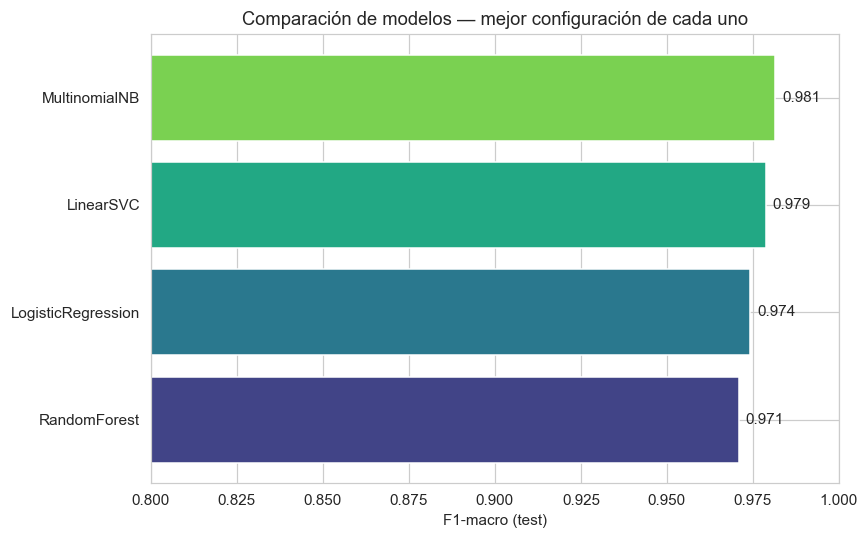

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
order = results_df.sort_values("test_f1_macro")["modelo"]
colors = sns.color_palette("viridis", len(order))
ax.barh(results_df.sort_values("test_f1_macro")["modelo"],
        results_df.sort_values("test_f1_macro")["test_f1_macro"], color=colors)
ax.set_xlabel("F1-macro (test)")
ax.set_title("Comparación de modelos — mejor configuración de cada uno")
ax.set_xlim(0.8, 1.0)
for i, v in enumerate(results_df.sort_values("test_f1_macro")["test_f1_macro"]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.savefig("figs/02_comparacion_modelos.png", bbox_inches="tight")
plt.show()

### 4.1 Efecto de los factores de vectorización (promediado sobre modelos)

Para aislar el efecto de vectorización y n-gramas independientemente del modelo, se extraen
todas las combinaciones evaluadas en la búsqueda (no solo las óptimas) y se agregan por factor.

In [8]:
# Reutilizamos las evaluaciones ya calculadas en la sección 3 (todas las combinaciones del
# grid de cada modelo), en lugar de repetir la búsqueda.
factor_df = pd.DataFrame(all_rows)
factor_summary = factor_df.groupby(["vectorizador", "ngram_range"])["f1_macro_cv"].agg(["mean", "std", "count"])
print(factor_summary)

                                 mean       std  count
vectorizador    ngram_range                           
CountVectorizer (1, 1)       0.961686  0.005609     13
                (1, 2)       0.961078  0.006038     13
TfidfVectorizer (1, 1)       0.956540  0.017599     13
                (1, 2)       0.955409  0.017251     13


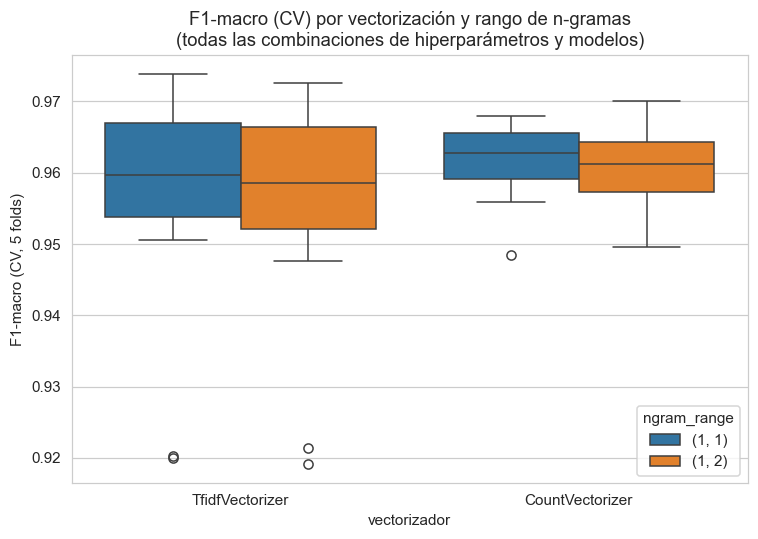

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=factor_df, x="vectorizador", y="f1_macro_cv", hue="ngram_range", ax=ax)
ax.set_title("F1-macro (CV) por vectorización y rango de n-gramas\n(todas las combinaciones de hiperparámetros y modelos)")
ax.set_ylabel("F1-macro (CV, 5 folds)")
plt.tight_layout()
plt.savefig("figs/03_efecto_vectorizacion.png", bbox_inches="tight")
plt.show()

## 5. Prueba de hipótesis: ¿es significativa la diferencia entre los dos mejores modelos?

H0: no hay diferencia en el F1-macro promedio (por fold de CV) entre el mejor y el segundo
mejor modelo. H1: sí la hay. Se usa una prueba t pareada sobre los 5 folds, dado que ambos
modelos se evaluaron sobre las mismas particiones.

In [10]:
top2 = results_df.sort_values("test_f1_macro", ascending=False)["modelo"].tolist()[:2]
scores_a = cv_scores_best[top2[0]]
scores_b = cv_scores_best[top2[1]]

t_stat, p_value = stats.ttest_rel(scores_a, scores_b)
print(f"Comparando {top2[0]} vs {top2[1]}")
print(f"F1-macro por fold ({top2[0]}): {np.round(scores_a, 4)}")
print(f"F1-macro por fold ({top2[1]}): {np.round(scores_b, 4)}")
print(f"t = {t_stat:.3f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("=> Diferencia estadísticamente significativa al 95% de confianza.")
else:
    print("=> No se puede rechazar H0: la diferencia no es estadísticamente significativa.")

Comparando MultinomialNB vs LinearSVC
F1-macro por fold (MultinomialNB): [0.9718 0.9453 0.969  0.9909 0.9626]
F1-macro por fold (LinearSVC): [0.9711 0.9605 0.9752 0.9885 0.9685]
t = -1.554, p-value = 0.1951
=> No se puede rechazar H0: la diferencia no es estadísticamente significativa.


## 6. Matriz de confusión del mejor modelo global

               precision    recall  f1-score   support

     business       1.00      0.95      0.97       102
entertainment       0.96      0.99      0.97        77
     politics       0.95      0.99      0.97        84
        sport       1.00      1.00      1.00       102
         tech       0.99      0.99      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



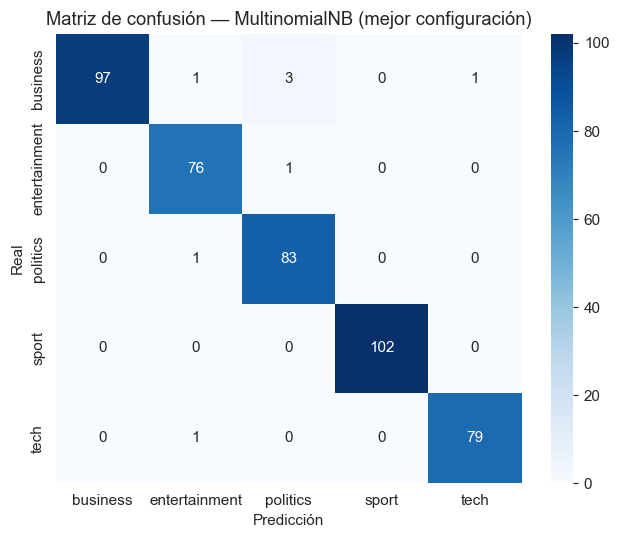

In [11]:
best_model_name = results_df.iloc[0]["modelo"]
best_model = best_estimators[best_model_name]
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best, labels=sorted(df["category"].unique()))
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(df["category"].unique()),
            yticklabels=sorted(df["category"].unique()), ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión — {best_model_name} (mejor configuración)")
plt.tight_layout()
plt.savefig("figs/04_matriz_confusion.png", bbox_inches="tight")
plt.show()

## 7. Conclusiones del experimento

Ver reporte (`reporte_diseno_experimentos.md` / `.pdf`) para la discusión completa de
hallazgos, metodología y recomendaciones de negocio/investigación derivadas de este diseño
factorial.

In [12]:
with open("resumen_resultados.json", "w") as f:
    json.dump({
        "resultados_por_modelo": results_df.to_dict(orient="records"),
        "factor_summary": factor_summary.reset_index().to_dict(orient="records"),
        "prueba_t": {"modelo_a": top2[0], "modelo_b": top2[1],
                     "t_stat": t_stat, "p_value": p_value},
        "mejor_modelo_global": best_model_name,
    }, f, indent=2, default=str)
print("Listo.")

Listo.
